In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = pd.read_csv("clv_dataset.csv")
dataset.head()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
0,1,45,Male,Bangalore,North,34,130,11,22049.35,1939.69,...,0.177,1077,Budget,0,4.7,0.126,1,16.91,116,48482.24
1,2,55,Female,Hyderabad,East,29,115,12,9864.60,930.01,...,0.081,694,Budget,0,3.1,0.178,4,11.15,57,36361.03
2,3,61,Male,Pune,South,11,195,15,27296.93,1546.24,...,0.184,999,Regular,0,3.6,0.231,1,25.61,116,46998.61
3,4,43,Female,Mumbai,Central,32,40,11,14348.10,1493.76,...,0.340,254,Budget,0,1.6,0.156,2,17.64,77,44372.90
4,5,60,Male,Mumbai,West,14,17,13,14451.23,1246.99,...,0.555,332,Budget,0,3.5,0.000,0,14.54,14,48491.85


In [3]:
x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [4]:
x.head()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,app_visits_per_month,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days
0,1,45,Male,Bangalore,North,34,130,11,22049.35,1939.69,...,19,0.177,1077,Budget,0,4.7,0.126,1,16.91,116
1,2,55,Female,Hyderabad,East,29,115,12,9864.60,930.01,...,15,0.081,694,Budget,0,3.1,0.178,4,11.15,57
2,3,61,Male,Pune,South,11,195,15,27296.93,1546.24,...,16,0.184,999,Regular,0,3.6,0.231,1,25.61,116
3,4,43,Female,Mumbai,Central,32,40,11,14348.10,1493.76,...,14,0.340,254,Budget,0,1.6,0.156,2,17.64,77
4,5,60,Male,Mumbai,West,14,17,13,14451.23,1246.99,...,9,0.555,332,Budget,0,3.5,0.000,0,14.54,14


In [5]:
y.head()

0    48482.24
1    36361.03
2    46998.61
3    44372.90
4    48491.85
Name: future_clv, dtype: float64

In [6]:
numeric_feature = x.select_dtypes(exclude=["object"]).columns
catag_feature = x.select_dtypes(include=["object"]).columns

In [7]:
numeric_feature

Index(['customer_id', 'age', 'tenure_months', 'recency_days',
       'frequency_orders', 'total_spent', 'avg_order_value', 'max_order_value',
       'min_order_value', 'last_purchase_value', 'discount_usage',
       'returns_count', 'app_visits_per_month', 'email_click_rate',
       'loyalty_points', 'complaints', 'satisfaction_score', 'churn_risk',
       'referral_count', 'avg_session_time', 'last_login_days'],
      dtype='object')

In [8]:
catag_feature

Index(['gender', 'city', 'region', 'product_category', 'payment_method',
       'customer_segment'],
      dtype='object')

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(capping_method="iqr", tail="both", fold=1.5)),
    ("scaler", MinMaxScaler())
])

In [10]:
catag_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

In [11]:
preprocess_pipeline = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_feature),
    ("catag", catag_pipeline, catag_feature)
])

In [12]:
clean = preprocess_pipeline.fit(x)

In [13]:
Clean_data = pd.DataFrame(clean.transform(x))

In [14]:
Clean_data.head()

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,0.00000,0.529412,0.471429,0.354396,0.166667,0.278862,0.518775,0.305566,0.326697,0.515300,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00001,0.725490,0.400000,0.313187,0.208333,0.112663,0.217689,0.201680,0.094926,0.147064,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.00002,0.843137,0.142857,0.532967,0.333333,0.350439,0.401448,0.330903,0.323162,0.417540,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.00003,0.490196,0.442857,0.107143,0.166667,0.173818,0.385799,0.526506,0.456262,0.429295,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.00004,0.823529,0.185714,0.043956,0.250000,0.175225,0.312212,0.427357,0.227452,0.221358,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:
joblib.dump(clean, "random_forest_preprocess_pipeline.pkl")

['random_forest_preprocess_pipeline.pkl']

In [16]:
joblib.load("random_forest_preprocess_pipeline.pkl")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('catag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    Clean_data, y, test_size=0.2, random_state=42
)

In [18]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [19]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [21]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.9802933142952515
Testing R2 Score: 0.8573497170028744


In [22]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print("Training Mean squared error: ", train_mse)
print("Testing Mean squared error: ", test_mse)

Training Mean squared error:  13066167.1192501
Testing Mean squared error:  96539323.87023814


In [23]:
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
print("Training Root mean squared error: ", train_rmse)
print("Testing Root mean squared error: ", test_rmse)

Training Root mean squared error:  3614.7153579846504
Testing Root mean squared error:  9825.44268062453


In [35]:
joblib.dump(model, "random_forest.pkl")

['random_forest.pkl']

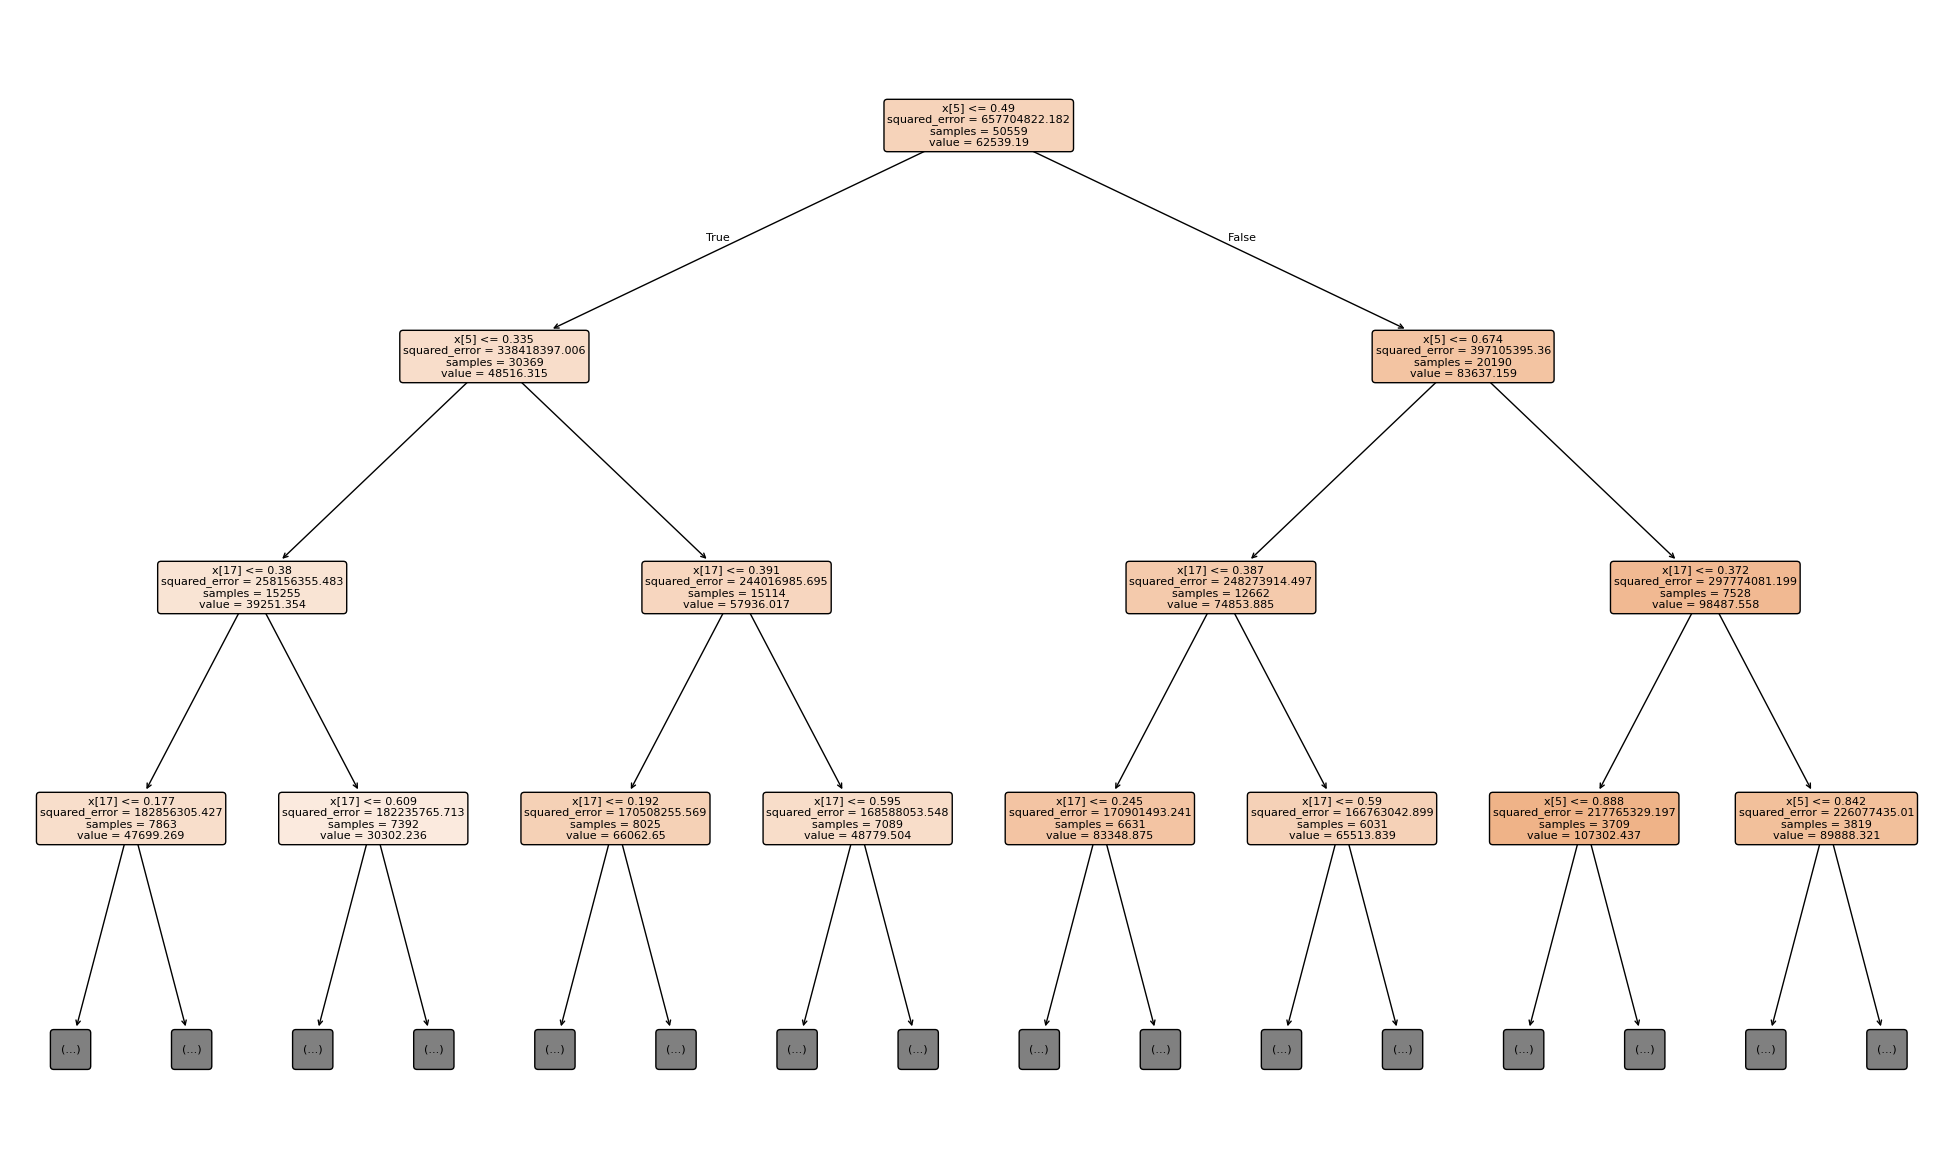

In [38]:
plt.figure(figsize=(25, 15))

tree.plot_tree(
    model.estimators_[0],   # first tree from Random Forest
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.show()